In [1]:
import json
from pathlib import Path
from itertools import product
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))

from simulators.CA_modified import CellularAutomaton_humidity_age
from simulators.metrics import FireMetrics

# Grid search

In this notebook, we estimate the unknown parameters using a grid search. We define several possible values for alpha, beta and gamma, and we test every possible combination. For each triplet of parameters, we simulate the fires again using the same terrain, age map, moisture map, wind maps and ignition points as in the observed dataset. Then, we compare the simulated fires with the reference fires using metrics such as the IoU and the average arrival time difference. The best parameters are the ones that give the smallest error on average over all fires.

First, we open the synthetic data.

In [3]:
DATASET_DIR = Path("synthetic_fire_dataset")

env = np.load(DATASET_DIR / "common_maps.npz")
height_grid = env["height_grid"]
age_grid = env["age_grid"]
moisture_grid = env["moisture_grid"]

with open(DATASET_DIR / "dataset_index.json", "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

print("Nombre de feux :", len(dataset_index))
print("Shape :", height_grid.shape)

with open(DATASET_DIR / "config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

N_STEPS = config["N_STEPS"]
print("N_STEPS used for evaluation:", N_STEPS)

Nombre de feux : 20
Shape : (100, 100)
N_STEPS used for evaluation: 20


Then we simulate a fire event : the ignition point is the same as in the synthetic data.

In [10]:
def make_phi(gamma):
    def phi(delta_h):
        if delta_h <= 0:
            return np.exp(gamma * delta_h)
        else:
            return 1.0 + gamma * np.sqrt(delta_h)
    return phi

def make_psi(beta):
    def psi(m):
        return np.exp(-beta * m)
    return psi

In [11]:
def initialize_single_ignition(ca, ignition_point, value=0.8):
    i0, j0 = int(ignition_point[0]), int(ignition_point[1])
    ca.initialize_ignition([(i0, j0)], [value])

In [ ]:
def simulate_fire_candidate(
    height_grid,
    age_grid,
    moisture_grid,
    wind_grid,
    ignition_point,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
):
    """Simulate a fire spread using the CellularAutomaton_humidity_age model with given parameters."""
    H, W = height_grid.shape

    ca = CellularAutomaton_humidity_age(
        grid_height=H,
        grid_width=W,
        wind_grid=wind_grid,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=make_phi(gamma),
        psi=make_psi(beta),
        alpha_age=alpha,
    )

    initialize_single_ignition(ca, ignition_point, value=0.8)

    arrival_time = -np.ones((H, W), dtype=np.int16)
    state0 = ca.get_state().copy()
    arrival_time[state0 >= 0.5] = 0

    for step in range(n_steps):
        ca.evolve(use_age=True, use_moisture=True)

        state = ca.get_state().copy()
        new_cells = (state >= 0.5) & (arrival_time < 0)
        arrival_time[new_cells] = step + 1

    return {
        "final_state": ca.get_state().copy().astype(np.float32),
        "arrival_time": arrival_time,
    }

Evaluation

In [ ]:
def iou_score(pred, obs, tau=0.5):
    """Compute the Intersection over Union (IoU) score between predicted and observed fire spread."""
    pred_bin = pred >= tau
    obs_bin = obs >= tau

    inter = np.logical_and(pred_bin, obs_bin).sum()
    union = np.logical_or(pred_bin, obs_bin).sum()

    if union == 0:
        return 1.0
    return inter / union

In [ ]:
def evaluate_one_fire_metrics(
    fire_path,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
    tau=0.5,
):
    """Evaluate the IoU and AATD metrics for a single fire spread simulation against observed data."""
    # Load observed data
    obs = np.load(fire_path)

    wind_grid = obs["wind_grid"].astype(np.float32)
    ignition_point = obs["ignition_point"].astype(np.int16)
    obs_final = obs["final_state"].astype(np.float32) / 255.0
    obs_arrival = obs["arrival_time"].astype(np.int16)

    # Simulate fire spread with candidate parameters
    pred = simulate_fire_candidate(
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        wind_grid=wind_grid,
        ignition_point=ignition_point,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=n_steps,
    )

    pred_final = pred["final_state"]
    pred_arrival = pred["arrival_time"]
    # Compute metrics
    iou = iou_score(pred_final, obs_final, tau=tau)
    aatd = FireMetrics.aatd_from_maps(pred_arrival, obs_arrival)

    return {
        "iou": float(iou),
        "iou_loss": float(1.0 - iou),
        "aatd": float(aatd) if np.isfinite(aatd) else np.nan,
    }

In [ ]:
def evaluate_params_metrics(
    fire_paths,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
    tau=0.5,
):
    """Evaluate the average IoU and AATD metrics across multiple fire simulations for given parameters."""
    scores = []
    # Evaluate each fire in the dataset and collect scores
    for fire_path in fire_paths:
        s = evaluate_one_fire_metrics(
            fire_path=fire_path,
            height_grid=height_grid,
            age_grid=age_grid,
            moisture_grid=moisture_grid,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            n_steps=n_steps,
            tau=tau,
        )
        scores.append(s)

    mean_iou = float(np.mean([s["iou"] for s in scores]))
    mean_iou_loss = float(np.mean([s["iou_loss"] for s in scores]))

    valid_aatd = [s["aatd"] for s in scores if np.isfinite(s["aatd"])]
    mean_aatd = float(np.mean(valid_aatd)) if len(valid_aatd) > 0 else np.nan

    return {
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "mean_iou": mean_iou,
        "mean_iou_loss": mean_iou_loss,
        "mean_aatd": mean_aatd,
    }

LAUNCH SIMULATIONS :
We define the grid search here

In [16]:
alpha_grid = [0.8,1.8, 2.0, 2.2, 4.0]
beta_grid  = [0.5,1.5, 2.0, 2.5, 5.0]
gamma_grid = [0.4,1, 1.2, 1.5,3.0]

N_EVAL_FIRES = 10

fire_paths = [
    DATASET_DIR / item["file"]
    for item in dataset_index[:N_EVAL_FIRES]
]

print("Nombre de triplets testés :", len(alpha_grid) * len(beta_grid) * len(gamma_grid))
print("Nombre de feux utilisés :", len(fire_paths))

Nombre de triplets testés : 125
Nombre de feux utilisés : 10


In [17]:
results = []

for alpha, beta, gamma in product(alpha_grid, beta_grid, gamma_grid):
    print(f"Test alpha={alpha}, beta={beta}, gamma={gamma}")

    row = evaluate_params_metrics(
        fire_paths=fire_paths,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=N_STEPS,
        tau=0.5,
    )

    results.append(row)

results_df = pd.DataFrame(results)

Test alpha=0.8, beta=0.5, gamma=0.4
Test alpha=0.8, beta=0.5, gamma=1
Test alpha=0.8, beta=0.5, gamma=1.2
Test alpha=0.8, beta=0.5, gamma=1.5
Test alpha=0.8, beta=0.5, gamma=3.0
Test alpha=0.8, beta=1.5, gamma=0.4
Test alpha=0.8, beta=1.5, gamma=1
Test alpha=0.8, beta=1.5, gamma=1.2
Test alpha=0.8, beta=1.5, gamma=1.5
Test alpha=0.8, beta=1.5, gamma=3.0
Test alpha=0.8, beta=2.0, gamma=0.4
Test alpha=0.8, beta=2.0, gamma=1
Test alpha=0.8, beta=2.0, gamma=1.2
Test alpha=0.8, beta=2.0, gamma=1.5
Test alpha=0.8, beta=2.0, gamma=3.0
Test alpha=0.8, beta=2.5, gamma=0.4
Test alpha=0.8, beta=2.5, gamma=1
Test alpha=0.8, beta=2.5, gamma=1.2
Test alpha=0.8, beta=2.5, gamma=1.5
Test alpha=0.8, beta=2.5, gamma=3.0
Test alpha=0.8, beta=5.0, gamma=0.4
Test alpha=0.8, beta=5.0, gamma=1
Test alpha=0.8, beta=5.0, gamma=1.2
Test alpha=0.8, beta=5.0, gamma=1.5
Test alpha=0.8, beta=5.0, gamma=3.0
Test alpha=1.8, beta=0.5, gamma=0.4
Test alpha=1.8, beta=0.5, gamma=1
Test alpha=1.8, beta=0.5, gamma=1.2
Test

In [18]:
df = results_df.copy()
results_df.sort_values("mean_iou_loss").head(10)

best = results_df.sort_values("mean_iou_loss").iloc[0]

print("Best parameters :")
print(best[["alpha", "beta", "gamma", "mean_iou", "mean_iou_loss"]])

Best parameters :
alpha            2.0
beta             2.0
gamma            1.2
mean_iou         1.0
mean_iou_loss    0.0
Name: 62, dtype: float64


In [19]:
print(results_df.sort_values("mean_iou_loss"))

     alpha  beta  gamma  mean_iou  mean_iou_loss  mean_aatd
62     2.0   2.0    1.2  1.000000       0.000000   0.000000
61     2.0   2.0    1.0  0.992233       0.007767   0.047188
63     2.0   2.0    1.5  0.988829       0.011171   0.060756
36     1.8   2.0    1.0  0.971842       0.028158   0.182284
88     2.2   2.0    1.5  0.970908       0.029092   0.182505
..     ...   ...    ...       ...            ...        ...
95     2.2   5.0    0.4  0.176176       0.823824   7.587305
123    4.0   5.0    1.5  0.175201       0.824799   6.180785
122    4.0   5.0    1.2  0.172625       0.827375   6.273217
121    4.0   5.0    1.0  0.171090       0.828910   6.321200
120    4.0   5.0    0.4  0.164983       0.835017   6.245939

[125 rows x 6 columns]


In [43]:
results_df.sort_values("mean_iou", ascending=False).head(10)

,alpha,beta,gamma,mean_iou,mean_iou_loss,mean_aatd
62,2.0,2.0,1.2,1.000000,0.000000,0.000000
61,2.0,2.0,1.0,0.992233,0.007767,0.047188
63,2.0,2.0,1.5,0.988829,0.011171,0.060756
36,1.8,2.0,1.0,0.971842,0.028158,0.182284
88,2.2,2.0,1.5,0.970908,0.029092,0.182505
37,1.8,2.0,1.2,0.970270,0.029730,0.186894
60,2.0,2.0,0.4,0.969921,0.030079,0.189320
87,2.2,2.0,1.2,0.968772,0.031228,0.193951
35,1.8,2.0,0.4,0.965791,0.034209,0.225599
86,2.2,2.0,1.0,0.961825,0.038175,0.242218


## Visualisations

In [21]:
def simulate_fire_candidate_with_trajectory(
    height_grid,
    age_grid,
    moisture_grid,
    wind_grid,
    ignition_point,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
    save_steps=None,
):
    H, W = height_grid.shape

    ca = CellularAutomaton_humidity_age(
        grid_height=H,
        grid_width=W,
        wind_grid=wind_grid,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=make_phi(gamma),
        psi=make_psi(beta),
        alpha_age=alpha,
    )

    initialize_single_ignition(ca, ignition_point, value=0.8)

    if save_steps is None:
        save_steps = [0, n_steps]
    save_steps = sorted(set(int(s) for s in save_steps))

    snapshots = {}
    arrival_time = -np.ones((H, W), dtype=np.int16)

    state = ca.get_state().copy()
    arrival_time[state >= 0.5] = 0

    if 0 in save_steps:
        snapshots[0] = state.copy().astype(np.float32)

    for step in range(1, n_steps + 1):
        ca.evolve(use_age=True, use_moisture=True)
        state = ca.get_state().copy()

        new_cells = (state >= 0.5) & (arrival_time < 0)
        arrival_time[new_cells] = step

        if step in save_steps:
            snapshots[step] = state.copy().astype(np.float32)

    return {
        "snapshots": snapshots,
        "final_state": ca.get_state().copy().astype(np.float32),
        "arrival_time": arrival_time,
    }

Best parameters found:
alpha = 2.0, beta = 2.0, gamma = 1.2
mean_iou = 1.0000


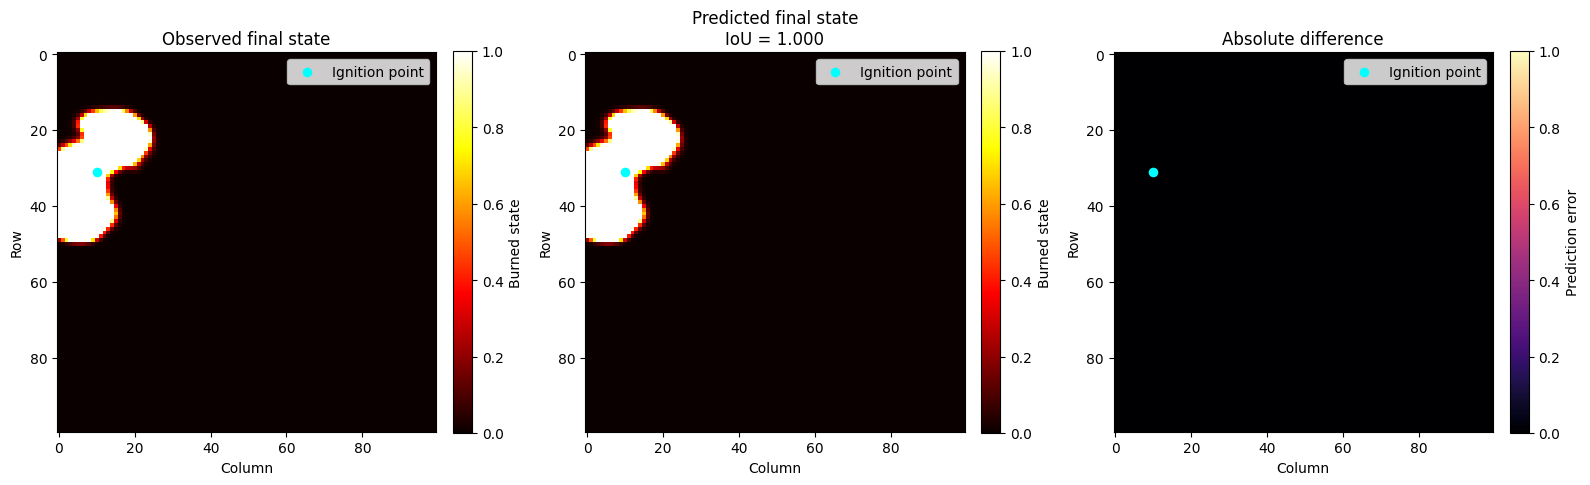

In [22]:
best = results_df.sort_values("mean_iou_loss").iloc[0]
best_alpha = float(best["alpha"])
best_beta = float(best["beta"])
best_gamma = float(best["gamma"])

print("Best parameters found:")
print(f"alpha = {best_alpha}, beta = {best_beta}, gamma = {best_gamma}")
print(f"mean_iou = {best['mean_iou']:.4f}")

fire_path = fire_paths[0]
obs = np.load(fire_path)

wind_grid = obs["wind_grid"].astype(np.float32)
ignition_point = obs["ignition_point"].astype(np.int16)
obs_final = obs["final_state"].astype(np.float32) / 255.0

pred = simulate_fire_candidate(
    height_grid=height_grid,
    age_grid=age_grid,
    moisture_grid=moisture_grid,
    wind_grid=wind_grid,
    ignition_point=ignition_point,
    alpha=best_alpha,
    beta=best_beta,
    gamma=best_gamma,
    n_steps=N_STEPS,
)

pred_final = pred["final_state"]
iou = iou_score(pred_final, obs_final, tau=0.5)

i0, j0 = int(ignition_point[0]), int(ignition_point[1])

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

im0 = axs[0].imshow(obs_final, cmap="hot", vmin=0, vmax=1)
axs[0].scatter([j0], [i0], c="cyan", s=35, label="Ignition point")
axs[0].set_title("Observed final state")
axs[0].set_xlabel("Column")
axs[0].set_ylabel("Row")
axs[0].legend(loc="upper right")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04, label="Burned state")

im1 = axs[1].imshow(pred_final, cmap="hot", vmin=0, vmax=1)
axs[1].scatter([j0], [i0], c="cyan", s=35, label="Ignition point")
axs[1].set_title(f"Predicted final state\nIoU = {iou:.3f}")
axs[1].set_xlabel("Column")
axs[1].set_ylabel("Row")
axs[1].legend(loc="upper right")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04, label="Burned state")

diff = np.abs(pred_final - obs_final)

im2 = axs[2].imshow(diff, cmap="magma", vmin=0, vmax=1)
axs[2].scatter([j0], [i0], c="cyan", s=35, label="Ignition point")
axs[2].set_title("Absolute difference")
axs[2].set_xlabel("Column")
axs[2].set_ylabel("Row")
axs[2].legend(loc="upper right")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04, label="Prediction error")

plt.tight_layout()
plt.show()

In [23]:
def plot_fire_comparison(
    fire_path,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps,
    step_indices=None,
):
    obs = np.load(fire_path)

    wind_grid = obs["wind_grid"].astype(np.float32)
    ignition_point = obs["ignition_point"].astype(np.int16)
    obs_saved_steps = obs["saved_steps"].astype(int)
    obs_snapshots = obs["snapshots"].astype(np.float32) / 255.0
    obs_final = obs["final_state"].astype(np.float32) / 255.0
    obs_arrival = obs["arrival_time"].astype(np.int16)

    if step_indices is None:
        idxs = np.unique(np.linspace(0, len(obs_saved_steps) - 1, 4, dtype=int))
    else:
        idxs = np.array(step_indices, dtype=int)

    selected_steps = obs_saved_steps[idxs].tolist()

    pred = simulate_fire_candidate_with_trajectory(
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        wind_grid=wind_grid,
        ignition_point=ignition_point,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=n_steps,
        save_steps=selected_steps,
    )

    pred_snapshots = pred["snapshots"]
    pred_final = pred["final_state"]
    pred_arrival = pred["arrival_time"]

    i0, j0 = int(ignition_point[0]), int(ignition_point[1])

    n_time_cols = len(selected_steps)
    n_cols = n_time_cols + 2
    fig, axs = plt.subplots(3, n_cols, figsize=(3.6 * n_cols, 9.5))

    for c, (idx, step) in enumerate(zip(idxs, selected_steps)):
        im = axs[0, c].imshow(obs_snapshots[idx], cmap="hot", vmin=0, vmax=1)
        axs[0, c].scatter([j0], [i0], c="cyan", s=25, label="Ignition point")
        axs[0, c].set_title(f"Observed t={step}")
        axs[0, c].set_xlabel("Column")
        axs[0, c].set_ylabel("Row")
        axs[0, c].legend(loc="upper right", fontsize="x-small")
        fig.colorbar(im, ax=axs[0, c], fraction=0.046, pad=0.04, label="Burned state")

    im = axs[0, n_time_cols].imshow(obs_final, cmap="hot", vmin=0, vmax=1)
    axs[0, n_time_cols].scatter([j0], [i0], c="cyan", s=25, label="Ignition point")
    axs[0, n_time_cols].set_title("Observed final")
    axs[0, n_time_cols].set_xlabel("Column")
    axs[0, n_time_cols].set_ylabel("Row")
    axs[0, n_time_cols].legend(loc="upper right", fontsize="x-small")
    fig.colorbar(im, ax=axs[0, n_time_cols], fraction=0.046, pad=0.04, label="Burned state")

    arr_gt_plot = np.where(obs_arrival >= 0, obs_arrival, np.nan)
    im = axs[0, n_time_cols + 1].imshow(arr_gt_plot, cmap="viridis")
    axs[0, n_time_cols + 1].scatter([j0], [i0], c="red", s=25, label="Ignition point")
    axs[0, n_time_cols + 1].set_title("Observed arrival time")
    axs[0, n_time_cols + 1].set_xlabel("Column")
    axs[0, n_time_cols + 1].set_ylabel("Row")
    axs[0, n_time_cols + 1].legend(loc="upper right", fontsize="x-small")
    fig.colorbar(im, ax=axs[0, n_time_cols + 1], fraction=0.046, pad=0.04, label="Arrival time step")

    for c, step in enumerate(selected_steps):
        im = axs[1, c].imshow(pred_snapshots[step], cmap="hot", vmin=0, vmax=1)
        axs[1, c].scatter([j0], [i0], c="cyan", s=25, label="Ignition point")
        axs[1, c].set_title(f"Predicted t={step}")
        axs[1, c].set_xlabel("Column")
        axs[1, c].set_ylabel("Row")
        axs[1, c].legend(loc="upper right", fontsize="x-small")
        fig.colorbar(im, ax=axs[1, c], fraction=0.046, pad=0.04, label="Burned state")

    im = axs[1, n_time_cols].imshow(pred_final, cmap="hot", vmin=0, vmax=1)
    axs[1, n_time_cols].scatter([j0], [i0], c="cyan", s=25, label="Ignition point")
    axs[1, n_time_cols].set_title("Predicted final")
    axs[1, n_time_cols].set_xlabel("Column")
    axs[1, n_time_cols].set_ylabel("Row")
    axs[1, n_time_cols].legend(loc="upper right", fontsize="x-small")
    fig.colorbar(im, ax=axs[1, n_time_cols], fraction=0.046, pad=0.04, label="Burned state")

    arr_pred_plot = np.where(pred_arrival >= 0, pred_arrival, np.nan)
    im = axs[1, n_time_cols + 1].imshow(arr_pred_plot, cmap="viridis")
    axs[1, n_time_cols + 1].scatter([j0], [i0], c="red", s=25, label="Ignition point")
    axs[1, n_time_cols + 1].set_title("Predicted arrival time")
    axs[1, n_time_cols + 1].set_xlabel("Column")
    axs[1, n_time_cols + 1].set_ylabel("Row")
    axs[1, n_time_cols + 1].legend(loc="upper right", fontsize="x-small")
    fig.colorbar(im, ax=axs[1, n_time_cols + 1], fraction=0.046, pad=0.04, label="Arrival time step")

    for c, (idx, step) in enumerate(zip(idxs, selected_steps)):
        diff_t = np.abs(pred_snapshots[step] - obs_snapshots[idx])
        im = axs[2, c].imshow(diff_t, cmap="magma", vmin=0, vmax=1)
        axs[2, c].scatter([j0], [i0], c="cyan", s=25, label="Ignition point")
        axs[2, c].set_title(f"Absolute difference t={step}")
        axs[2, c].set_xlabel("Column")
        axs[2, c].set_ylabel("Row")
        axs[2, c].legend(loc="upper right", fontsize="x-small")
        fig.colorbar(im, ax=axs[2, c], fraction=0.046, pad=0.04, label="Prediction error")

    final_diff = np.abs(pred_final - obs_final)
    final_iou = iou_score(pred_final, obs_final, tau=0.5)

    im = axs[2, n_time_cols].imshow(final_diff, cmap="magma", vmin=0, vmax=1)
    axs[2, n_time_cols].scatter([j0], [i0], c="cyan", s=25, label="Ignition point")
    axs[2, n_time_cols].set_title(f"Final absolute difference\nIoU = {final_iou:.3f}")
    axs[2, n_time_cols].set_xlabel("Column")
    axs[2, n_time_cols].set_ylabel("Row")
    axs[2, n_time_cols].legend(loc="upper right", fontsize="x-small")
    fig.colorbar(im, ax=axs[2, n_time_cols], fraction=0.046, pad=0.04, label="Prediction error")

    arrival_diff = np.full_like(pred_arrival, np.nan, dtype=float)
    valid = (pred_arrival >= 0) & (obs_arrival >= 0)
    arrival_diff[valid] = np.abs(pred_arrival[valid] - obs_arrival[valid])

    aatd_val = FireMetrics.aatd_from_maps(pred_arrival, obs_arrival)

    im = axs[2, n_time_cols + 1].imshow(arrival_diff, cmap="magma")
    axs[2, n_time_cols + 1].scatter([j0], [i0], c="cyan", s=25, label="Ignition point")
    axs[2, n_time_cols + 1].set_title(f"Arrival time difference\nAATD = {aatd_val:.3f}")
    axs[2, n_time_cols + 1].set_xlabel("Column")
    axs[2, n_time_cols + 1].set_ylabel("Row")
    axs[2, n_time_cols + 1].legend(loc="upper right", fontsize="x-small")
    fig.colorbar(im, ax=axs[2, n_time_cols + 1], fraction=0.046, pad=0.04, label="Time step error")

    plt.suptitle(
        f"{fire_path.name} | ignition={tuple(ignition_point.tolist())} | "
        f"alpha={alpha:.3f}, beta={beta:.3f}, gamma={gamma:.3f}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

Best parameters according to AATD:
alpha        2.0
beta         2.0
gamma        1.2
mean_iou     1.0
mean_aatd    0.0
Name: 62, dtype: float64


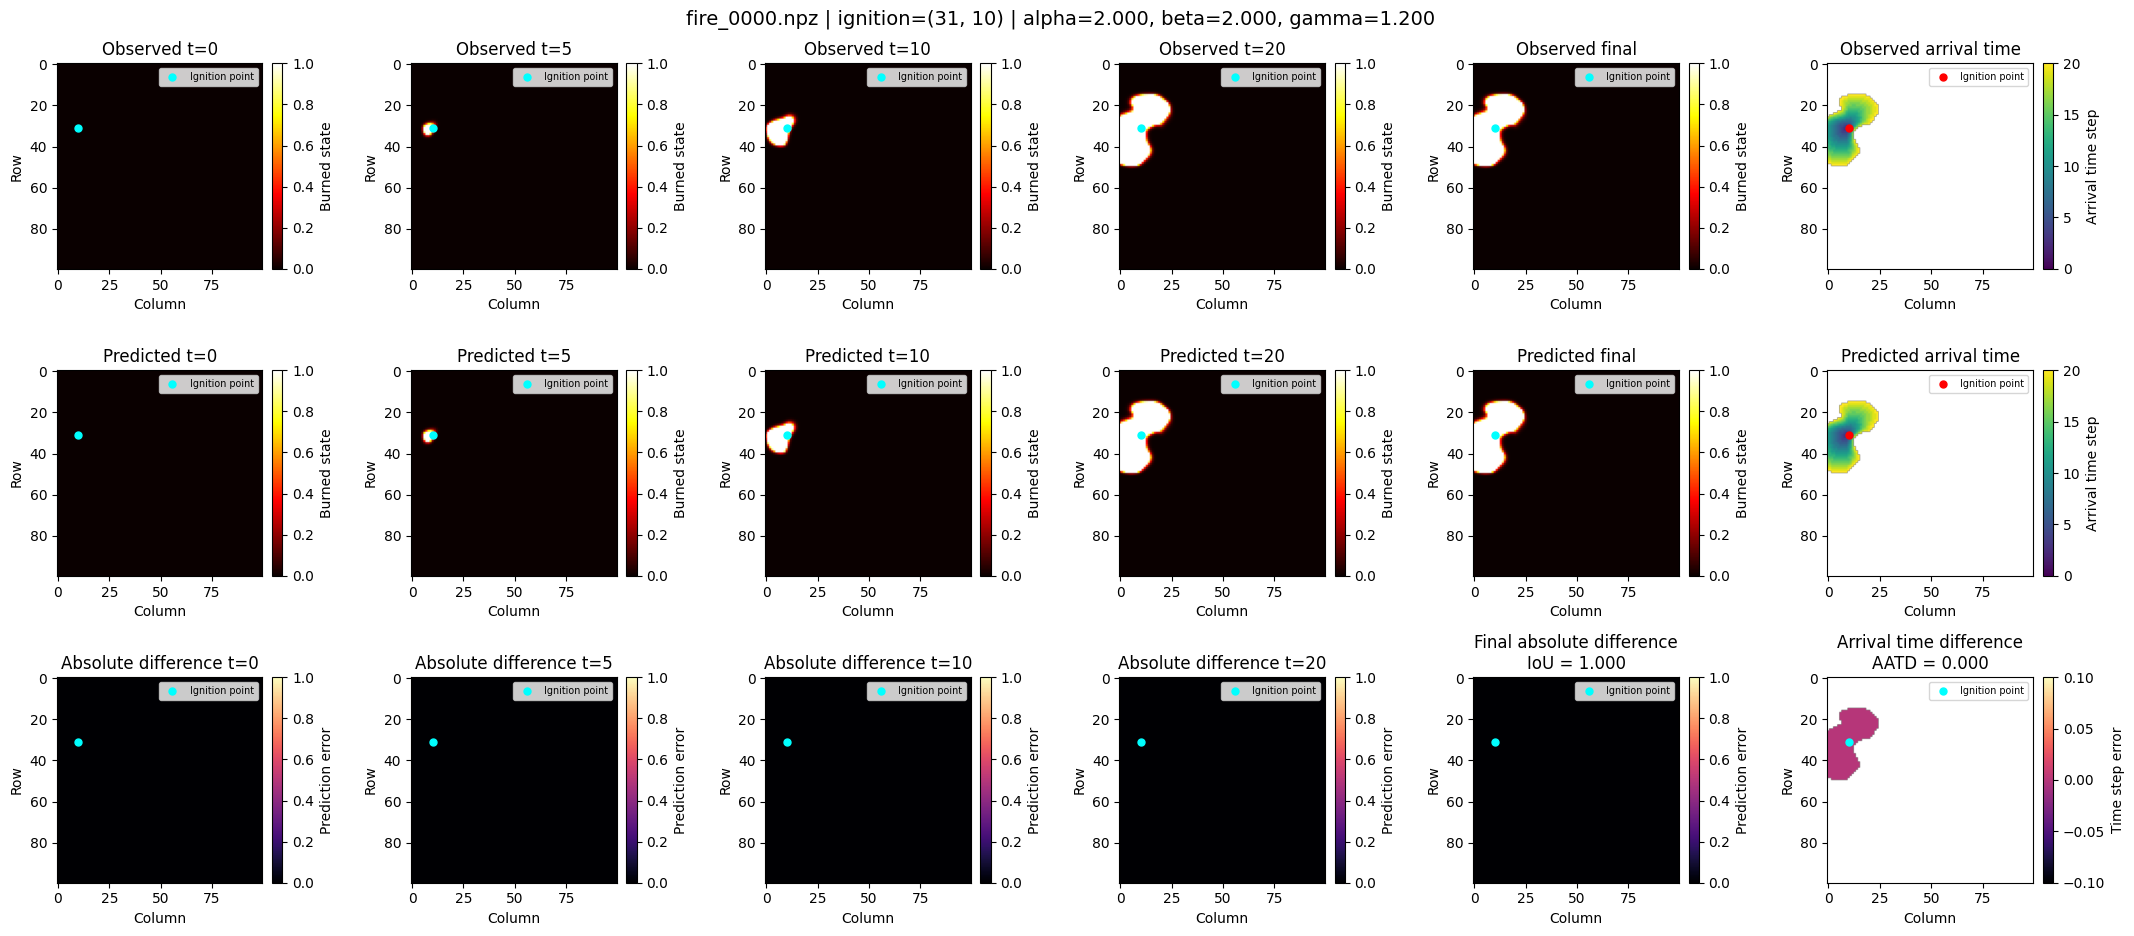

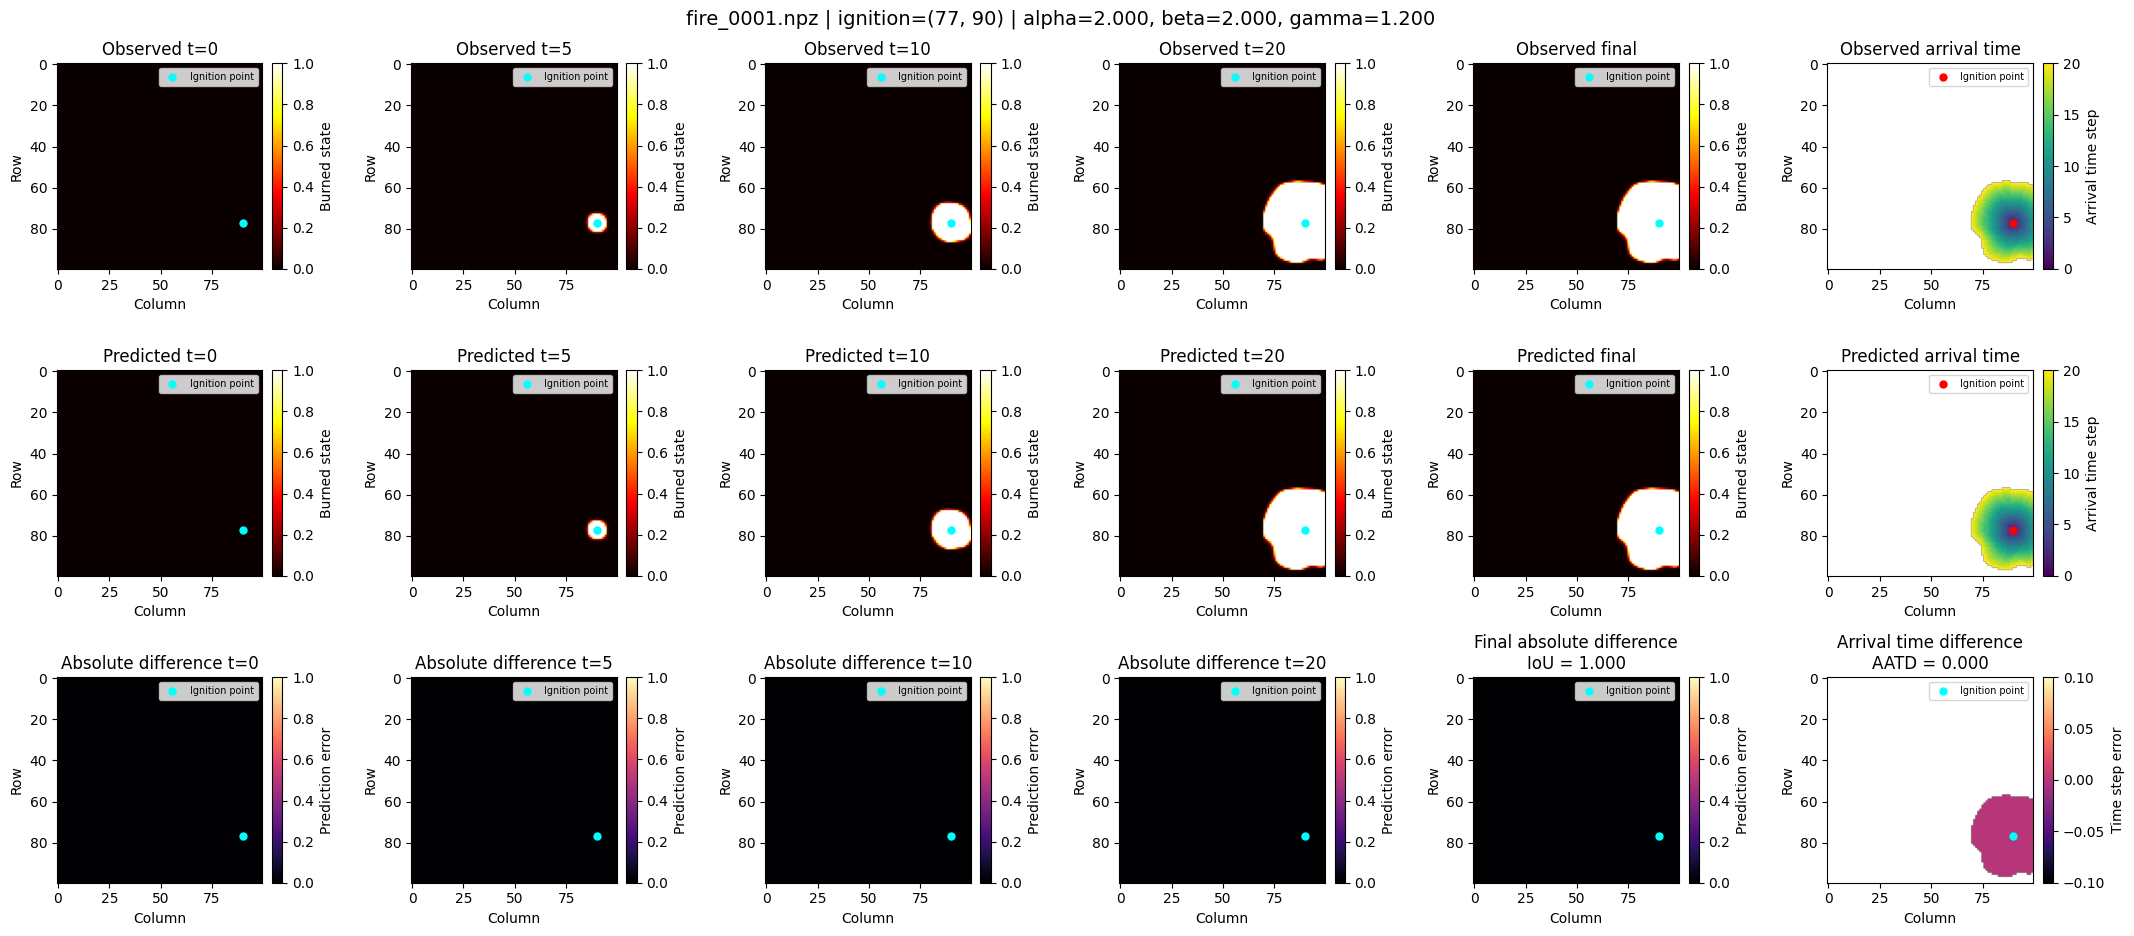

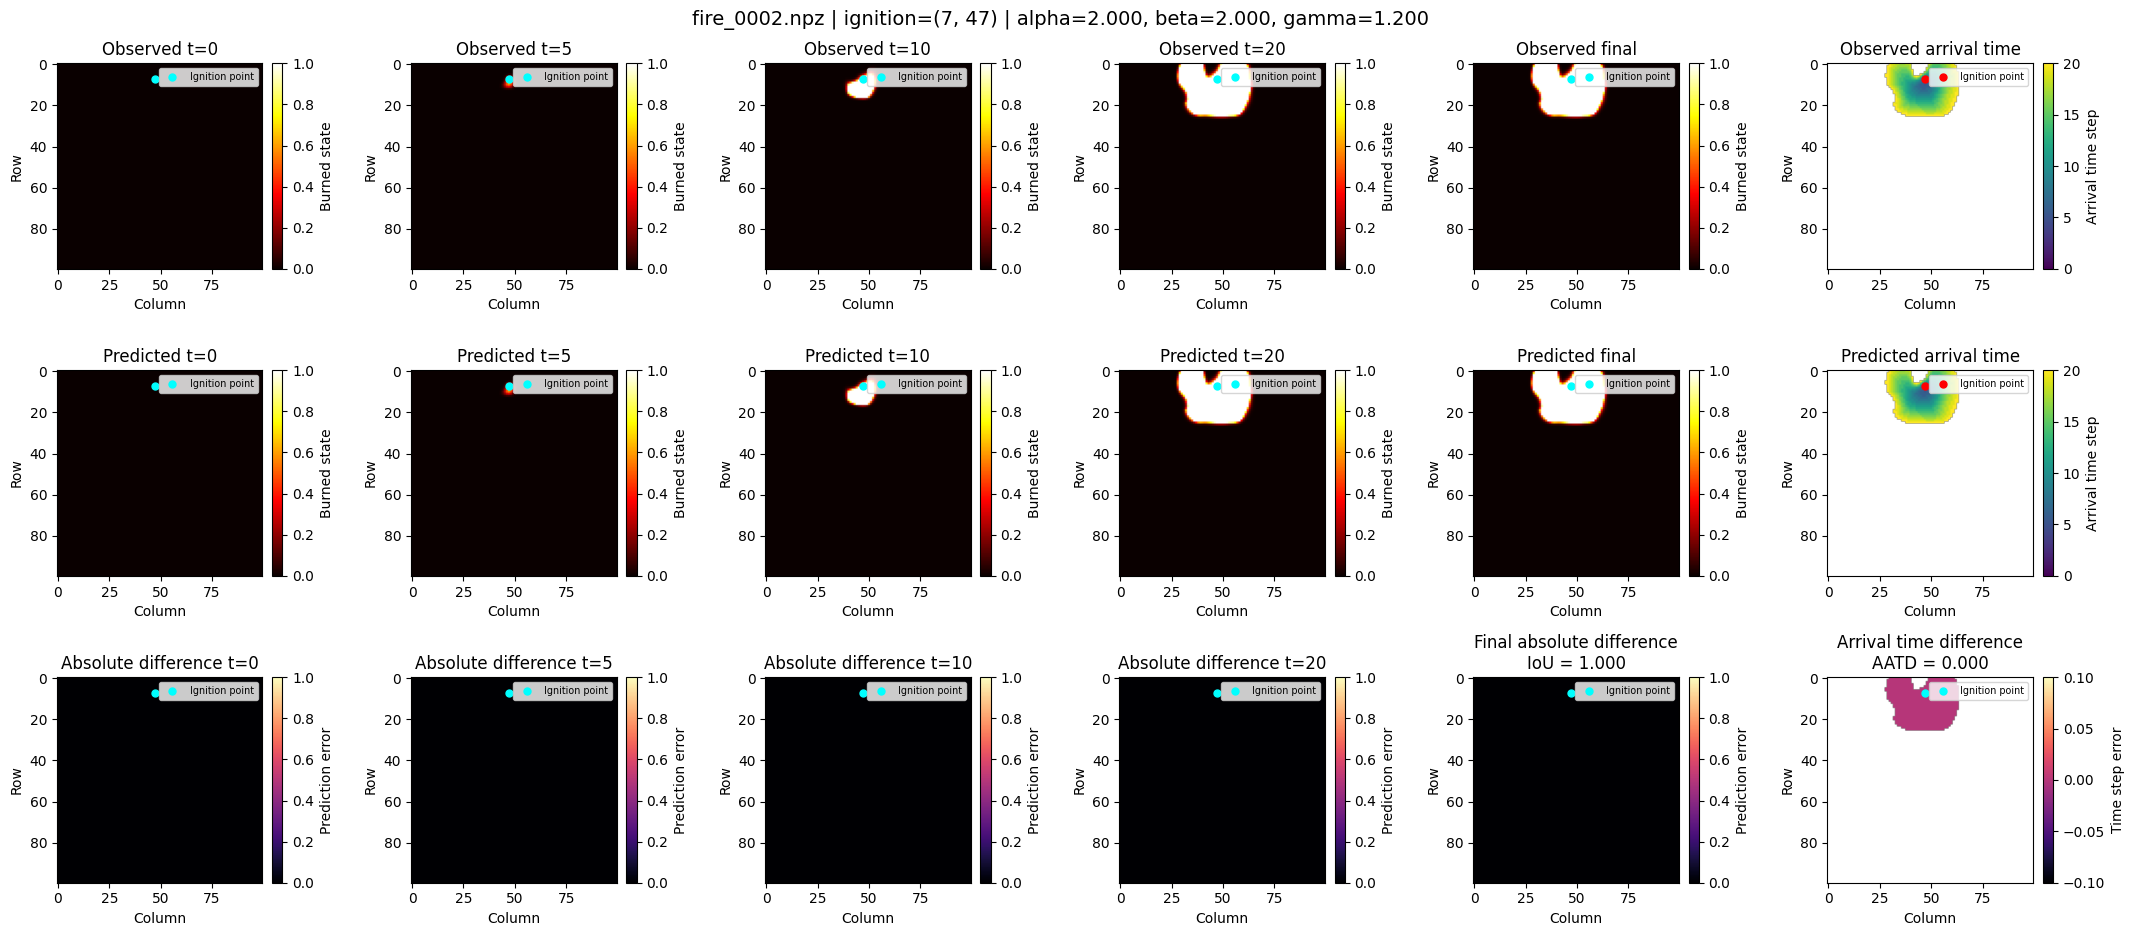

In [24]:
def get_best_params(results_df, criterion="mean_iou_loss", ascending=True):
    best = results_df.sort_values(criterion, ascending=ascending).iloc[0]
    return float(best["alpha"]), float(best["beta"]), float(best["gamma"]), best

# Choix du meilleur triplet
if "mean_aatd" in results_df.columns and results_df["mean_aatd"].notna().any():
    df_valid = results_df.dropna(subset=["mean_aatd"]).copy()
    best_alpha, best_beta, best_gamma, best_row = get_best_params(
        df_valid,
        criterion="mean_aatd"
    )
    print("Best parameters according to AATD:")
    print(best_row[["alpha", "beta", "gamma", "mean_iou", "mean_aatd"]])
else:
    best_alpha, best_beta, best_gamma, best_row = get_best_params(
        results_df,
        criterion="mean_iou_loss"
    )
    print("Best parameters according to IoU:")
    cols = ["alpha", "beta", "gamma", "mean_iou"]
    if "mean_iou_loss" in best_row.index:
        cols.append("mean_iou_loss")
    print(best_row[cols])

# Nombre de feux à afficher
N_SHOW = min(3, len(fire_paths))

# Affichage
for fire_path in fire_paths[:N_SHOW]:
    plot_fire_comparison(
        fire_path=fire_path,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        alpha=best_alpha,
        beta=best_beta,
        gamma=best_gamma,
        n_steps=N_STEPS,
    )

# Plots to evaluate the sensitivity to parameters

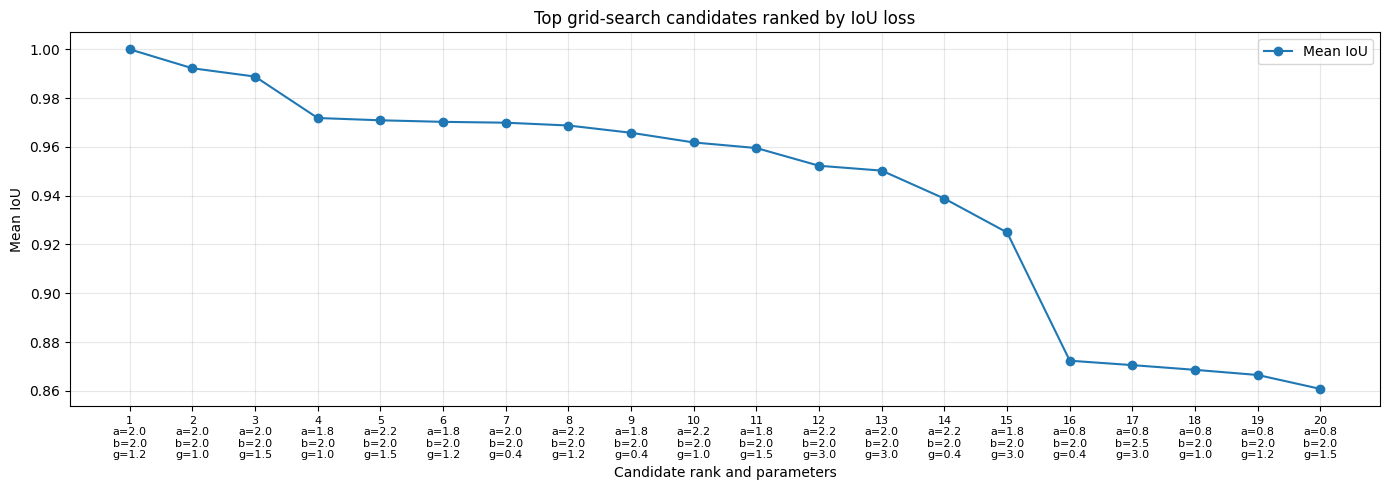

In [44]:
top_k = 20

df_top = results_df.sort_values("mean_iou_loss").head(top_k).copy()
df_top["candidate"] = np.arange(1, len(df_top) + 1)

df_top["label"] = df_top.apply(
    lambda row: (
        f"{int(row['candidate'])}\n"
        f"a={row['alpha']:.1f}\n"
        f"b={row['beta']:.1f}\n"
        f"g={row['gamma']:.1f}"
    ),
    axis=1
)

plt.figure(figsize=(14, 5))

plt.plot(
    df_top["candidate"],
    df_top["mean_iou"],
    marker="o",
    label="Mean IoU"
)

plt.xticks(
    ticks=df_top["candidate"],
    labels=df_top["label"],
    rotation=0,
    fontsize=8
)

plt.xlabel("Candidate rank and parameters")
plt.ylabel("Mean IoU")
plt.title("Top grid-search candidates ranked by IoU loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

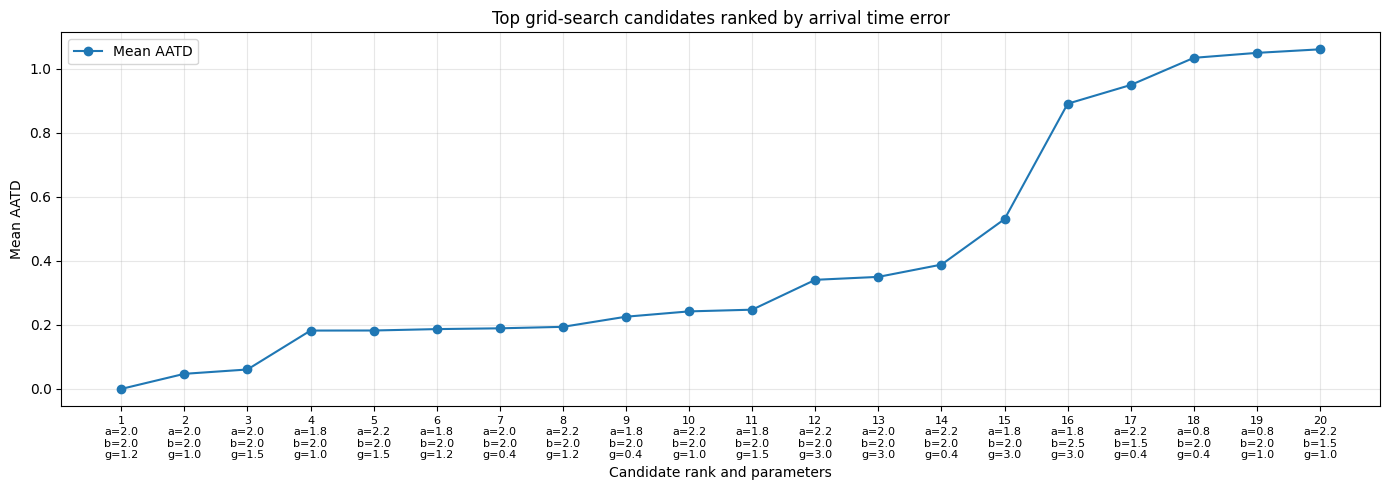

In [45]:
top_k = 20

df_top = (
    results_df
    .dropna(subset=["mean_aatd"])
    .sort_values("mean_aatd")
    .head(top_k)
    .copy()
)

df_top["candidate"] = np.arange(1, len(df_top) + 1)

df_top["label"] = df_top.apply(
    lambda row: (
        f"{int(row['candidate'])}\n"
        f"a={row['alpha']:.1f}\n"
        f"b={row['beta']:.1f}\n"
        f"g={row['gamma']:.1f}"
    ),
    axis=1
)

plt.figure(figsize=(14, 5))

plt.plot(
    df_top["candidate"],
    df_top["mean_aatd"],
    marker="o",
    label="Mean AATD"
)

plt.xticks(
    ticks=df_top["candidate"],
    labels=df_top["label"],
    rotation=0,
    fontsize=8
)

plt.xlabel("Candidate rank and parameters")
plt.ylabel("Mean AATD")
plt.title("Top grid-search candidates ranked by arrival time error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Heatmap

Fixed gamma: 1.2
Alpha values actually tested: [0.8 1.8 2.  2.2 4. ]
Beta values actually tested: [0.5 1.5 2.  2.5 5. ]

Best point in this alpha/beta slice:
alpha       2.0
beta        2.0
gamma       1.2
mean_iou    1.0
Name: 62, dtype: float64

Global best point:
alpha       2.0
beta        2.0
gamma       1.2
mean_iou    1.0
Name: 62, dtype: float64


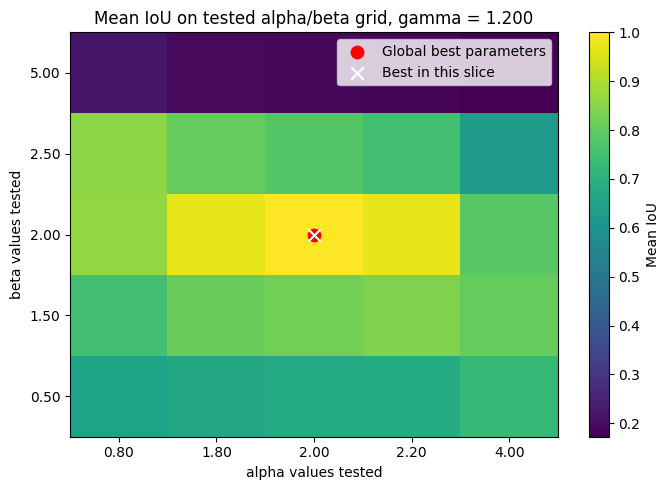

In [32]:
gamma_fixed = best_gamma

df_ab = results_df[np.isclose(results_df["gamma"], gamma_fixed)].copy()

heatmap_ab = df_ab.pivot_table(
    index="beta",
    columns="alpha",
    values="mean_iou"
)

alpha_values = heatmap_ab.columns.values
beta_values = heatmap_ab.index.values

print("Fixed gamma:", gamma_fixed)
print("Alpha values actually tested:", alpha_values)
print("Beta values actually tested:", beta_values)

best_in_slice = df_ab.sort_values("mean_iou", ascending=False).iloc[0]

print("\nBest point in this alpha/beta slice:")
print(best_in_slice[["alpha", "beta", "gamma", "mean_iou"]])

print("\nGlobal best point:")
print(best[["alpha", "beta", "gamma", "mean_iou"]])

plt.figure(figsize=(7, 5))

im = plt.imshow(
    heatmap_ab.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.xticks(
    ticks=np.arange(len(alpha_values)),
    labels=[f"{v:.2f}" for v in alpha_values]
)

plt.yticks(
    ticks=np.arange(len(beta_values)),
    labels=[f"{v:.2f}" for v in beta_values]
)

best_alpha_idx = np.where(np.isclose(alpha_values, best_alpha))[0]
best_beta_idx = np.where(np.isclose(beta_values, best_beta))[0]

if len(best_alpha_idx) > 0 and len(best_beta_idx) > 0:
    plt.scatter(
        best_alpha_idx[0],
        best_beta_idx[0],
        c="red",
        s=80,
        label="Global best parameters"
    )

slice_alpha_idx = np.where(np.isclose(alpha_values, best_in_slice["alpha"]))[0]
slice_beta_idx = np.where(np.isclose(beta_values, best_in_slice["beta"]))[0]

if len(slice_alpha_idx) > 0 and len(slice_beta_idx) > 0:
    plt.scatter(
        slice_alpha_idx[0],
        slice_beta_idx[0],
        c="white",
        s=80,
        marker="x",
        label="Best in this slice"
    )

plt.xlabel("alpha values tested")
plt.ylabel("beta values tested")
plt.title(f"Mean IoU on tested alpha/beta grid, gamma = {gamma_fixed:.3f}")
plt.legend(loc="upper right")
plt.colorbar(im, label="Mean IoU")
plt.tight_layout()
plt.show()

Fixed beta: 2.0
Alpha values actually tested: [0.8 1.8 2.  2.2 4. ]
Gamma values actually tested: [0.4 1.  1.2 1.5 3. ]

Best point in this alpha/gamma slice:
alpha       2.0
beta        2.0
gamma       1.2
mean_iou    1.0
Name: 62, dtype: float64

Global best point:
alpha       2.0
beta        2.0
gamma       1.2
mean_iou    1.0
Name: 62, dtype: float64


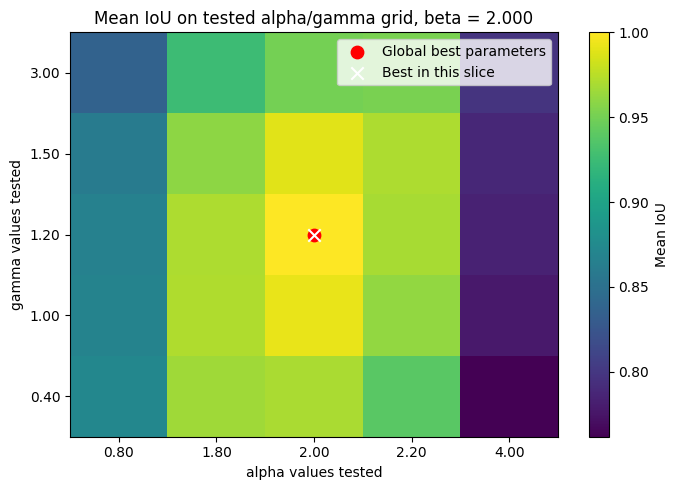

In [33]:
beta_fixed = best_beta

df_ag = results_df[np.isclose(results_df["beta"], beta_fixed)].copy()

heatmap_ag = df_ag.pivot_table(
    index="gamma",
    columns="alpha",
    values="mean_iou"
)

alpha_values = heatmap_ag.columns.values
gamma_values = heatmap_ag.index.values

print("Fixed beta:", beta_fixed)
print("Alpha values actually tested:", alpha_values)
print("Gamma values actually tested:", gamma_values)

best_in_slice = df_ag.sort_values("mean_iou", ascending=False).iloc[0]

print("\nBest point in this alpha/gamma slice:")
print(best_in_slice[["alpha", "beta", "gamma", "mean_iou"]])

print("\nGlobal best point:")
print(best[["alpha", "beta", "gamma", "mean_iou"]])

plt.figure(figsize=(7, 5))

im = plt.imshow(
    heatmap_ag.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.xticks(
    ticks=np.arange(len(alpha_values)),
    labels=[f"{v:.2f}" for v in alpha_values]
)

plt.yticks(
    ticks=np.arange(len(gamma_values)),
    labels=[f"{v:.2f}" for v in gamma_values]
)

best_alpha_idx = np.where(np.isclose(alpha_values, best_alpha))[0]
best_gamma_idx = np.where(np.isclose(gamma_values, best_gamma))[0]

if len(best_alpha_idx) > 0 and len(best_gamma_idx) > 0:
    plt.scatter(
        best_alpha_idx[0],
        best_gamma_idx[0],
        c="red",
        s=80,
        label="Global best parameters"
    )

slice_alpha_idx = np.where(np.isclose(alpha_values, best_in_slice["alpha"]))[0]
slice_gamma_idx = np.where(np.isclose(gamma_values, best_in_slice["gamma"]))[0]

if len(slice_alpha_idx) > 0 and len(slice_gamma_idx) > 0:
    plt.scatter(
        slice_alpha_idx[0],
        slice_gamma_idx[0],
        c="white",
        s=80,
        marker="x",
        label="Best in this slice"
    )

plt.xlabel("alpha values tested")
plt.ylabel("gamma values tested")
plt.title(f"Mean IoU on tested alpha/gamma grid, beta = {beta_fixed:.3f}")
plt.legend(loc="upper right")
plt.colorbar(im, label="Mean IoU")
plt.tight_layout()
plt.show()

Fixed alpha: 2.0
Beta values actually tested: [0.5 1.5 2.  2.5 5. ]
Gamma values actually tested: [0.4 1.  1.2 1.5 3. ]

Best point in this beta/gamma slice:
alpha       2.0
beta        2.0
gamma       1.2
mean_iou    1.0
Name: 62, dtype: float64

Global best point:
alpha       2.0
beta        2.0
gamma       1.2
mean_iou    1.0
Name: 62, dtype: float64


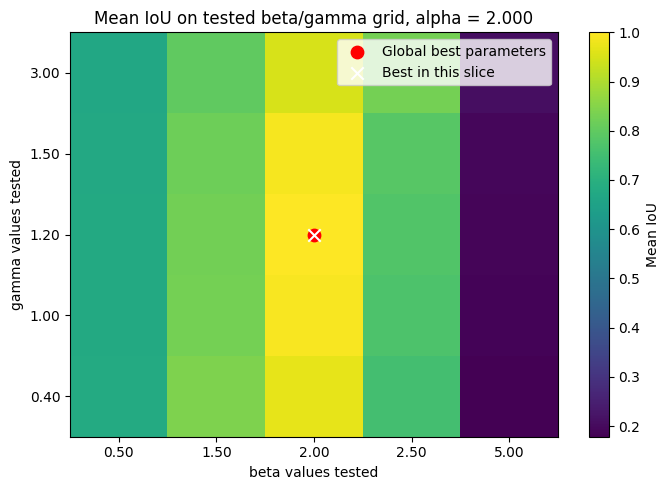

In [31]:
alpha_fixed = best_alpha

df_bg = results_df[np.isclose(results_df["alpha"], alpha_fixed)].copy()

heatmap_bg = df_bg.pivot_table(
    index="gamma",
    columns="beta",
    values="mean_iou"
)

beta_values = heatmap_bg.columns.values
gamma_values = heatmap_bg.index.values

print("Fixed alpha:", alpha_fixed)
print("Beta values actually tested:", beta_values)
print("Gamma values actually tested:", gamma_values)

best_in_slice = df_bg.sort_values("mean_iou", ascending=False).iloc[0]

print("\nBest point in this beta/gamma slice:")
print(best_in_slice[["alpha", "beta", "gamma", "mean_iou"]])

print("\nGlobal best point:")
print(best[["alpha", "beta", "gamma", "mean_iou"]])

plt.figure(figsize=(7, 5))

im = plt.imshow(
    heatmap_bg.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.xticks(
    ticks=np.arange(len(beta_values)),
    labels=[f"{v:.2f}" for v in beta_values]
)

plt.yticks(
    ticks=np.arange(len(gamma_values)),
    labels=[f"{v:.2f}" for v in gamma_values]
)

best_beta_idx = np.where(np.isclose(beta_values, best_beta))[0]
best_gamma_idx = np.where(np.isclose(gamma_values, best_gamma))[0]

if len(best_beta_idx) > 0 and len(best_gamma_idx) > 0:
    plt.scatter(
        best_beta_idx[0],
        best_gamma_idx[0],
        c="red",
        s=80,
        label="Global best parameters"
    )

slice_beta_idx = np.where(np.isclose(beta_values, best_in_slice["beta"]))[0]
slice_gamma_idx = np.where(np.isclose(gamma_values, best_in_slice["gamma"]))[0]

if len(slice_beta_idx) > 0 and len(slice_gamma_idx) > 0:
    plt.scatter(
        slice_beta_idx[0],
        slice_gamma_idx[0],
        c="white",
        s=80,
        marker="x",
        label="Best in this slice"
    )

plt.xlabel("beta values tested")
plt.ylabel("gamma values tested")
plt.title(f"Mean IoU on tested beta/gamma grid, alpha = {alpha_fixed:.3f}")
plt.legend(loc="upper right")
plt.colorbar(im, label="Mean IoU")
plt.tight_layout()
plt.show()